# Notebook 1 — Analyse Exploratoire des Données (EDA)
**Projet IndabaX 2026 — Cameroun** | Prédiction du Vector Risk Index (VRI) — *Anopheles gambiae*

Pipeline : Chargement → Nettoyage → Construction VRI → Exploration → Sauvegarde


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import skew, kurtosis
from sklearn.preprocessing import LabelEncoder
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

RANDOM_STATE = 42
TEST_YEAR    = 2025
HORIZONS     = [1, 7]
print('Imports OK.')


Imports OK.


## 1. Chargement et audit initial

In [2]:
df = pd.read_excel('../data/Dataset_complet_Meteo.xlsx')
print(f'Dimensions : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')
print(f'Villes     : {df["city"].nunique()} | Régions : {df["region"].nunique()}')
print()
print('Types de colonnes :')
print(df.dtypes.to_string())


Dimensions : 87,240 lignes x 26 colonnes
Villes     : 40 | Régions : 10

Types de colonnes :
id                                      int64
time                           datetime64[ns]
weather_code                            int64
temperature_2m_max                     object
temperature_2m_min                     object
temperature_2m_mean                    object
apparent_temperature_max               object
apparent_temperature_min               object
apparent_temperature_mean              object
sunrise                        datetime64[ns]
sunset                         datetime64[ns]
daylight_duration                     float64
sunshine_duration                      object
precipitation_sum                      object
rain_sum                               object
snowfall_sum                          float64
precipitation_hours                   float64
wind_speed_10m_max                     object
wind_gusts_10m_max                     object
wind_direction_10m_dominant      

## 2. Correction des types
`pd.to_numeric(errors='coerce')` convertit les valeurs corrompues en NaN sans supprimer de lignes.

In [3]:
NUMERIC_COLS = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'apparent_temperature_max', 'apparent_temperature_min', 'apparent_temperature_mean',
    'precipitation_sum', 'rain_sum', 'sunshine_duration',
    'wind_speed_10m_max', 'wind_gusts_10m_max',
    'shortwave_radiation_sum', 'et0_fao_evapotranspiration',
    'latitude', 'longitude',
]
nan_avant = df[NUMERIC_COLS].isnull().sum().sum()
for col in NUMERIC_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
nan_apres = df[NUMERIC_COLS].isnull().sum().sum()
print(f'NaN avant conversion : {nan_avant:,}')
print(f'NaN après conversion : {nan_apres:,}')
print(f'Valeurs corrompues   : {nan_apres - nan_avant:,}')


NaN avant conversion : 0
NaN après conversion : 657,408
Valeurs corrompues   : 657,408


## 3. Tri chronologique
Tri par `['city','time']` — le tri global sur `time` seul détruisait l'ordre intra-ville (bug corrigé).

In [4]:
df['time'] = pd.to_datetime(df['time'], errors='coerce')
df = df.sort_values(['city', 'time']).reset_index(drop=True)
print(f'Période : {df["time"].min().date()} -> {df["time"].max().date()}')
print()
print('Observations par ville :')
print(df.groupby('city')['time'].count().describe().round(0))
df['time_diff'] = df.groupby('city')['time'].diff().dt.days
gaps = df[df['time_diff'] > 1][['city', 'time', 'time_diff']]
if gaps.empty:
    print('\nAucun trou temporel — continuité journalière confirmée.')
else:
    print(f'{len(gaps)} ruptures détectées :\n{gaps.to_string(index=False)}')


Période : 2020-01-01 -> 2025-12-20

Observations par ville :
count      40.0
mean     2181.0
std         0.0
min      2181.0
25%      2181.0
50%      2181.0
75%      2181.0
max      2181.0
Name: time, dtype: float64

Aucun trou temporel — continuité journalière confirmée.


## 4. Audit des valeurs manquantes

In [5]:
missing     = df[NUMERIC_COLS].isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
audit = pd.DataFrame({'Manquants': missing, 'Pct (%)': missing_pct})
print(audit[audit['Manquants'] > 0].to_string())


                            Manquants  Pct (%)
wind_speed_10m_max              77862     89.3
apparent_temperature_min        77672     89.0
temperature_2m_mean             75732     86.8
temperature_2m_min              75235     86.2
apparent_temperature_mean       69563     79.7
temperature_2m_max              53906     61.8
wind_gusts_10m_max              45573     52.2
rain_sum                        39471     45.2
precipitation_sum               39471     45.2
apparent_temperature_max        30896     35.4
longitude                       23991     27.5
shortwave_radiation_sum         17342     19.9
et0_fao_evapotranspiration      17119     19.6
latitude                        13086     15.0
sunshine_duration                 489      0.6


## 5. Imputation adaptée par priorité
`groupby().transform()` évite les index dupliqués produits par `.apply()` (bug corrigé).

In [6]:
def impute_time_series(df, group_cols=('city', 'region')):
    df_out = df.copy().reset_index(drop=True)
    gc = list(group_cols)
    critical  = ['temperature_2m_mean','temperature_2m_max','temperature_2m_min',
                 'precipitation_sum','rain_sum']
    important = ['apparent_temperature_mean','apparent_temperature_max',
                 'apparent_temperature_min','et0_fao_evapotranspiration',
                 'wind_speed_10m_max','wind_gusts_10m_max']
    secondary = ['sunshine_duration','shortwave_radiation_sum']
    for col in critical:
        if col in df_out.columns:
            df_out[col] = df_out.groupby(gc)[col].transform(
                lambda x: x.ffill().bfill())
    for col in important:
        if col in df_out.columns:
            df_out[col] = df_out.groupby(gc)[col].transform(
                lambda x: x.interpolate(method='linear').ffill().bfill())
    for col in secondary:
        if col in df_out.columns:
            df_out[col] = df_out.groupby(gc)[col].transform(
                lambda x: x.rolling(14, min_periods=5, center=True).mean().ffill().bfill())
    for col in ['latitude', 'longitude']:
        if col in df_out.columns:
            df_out[col] = df_out.groupby('region')[col].transform(
                lambda x: x.fillna(x.median()))
    return df_out.reset_index(drop=True)

df_clean = impute_time_series(df)
nan_res = df_clean[NUMERIC_COLS].isnull().sum()
nan_res = nan_res[nan_res > 0]
if nan_res.empty:
    print('Imputation complète — aucun NaN résiduel.')
else:
    print('NaN résiduels :'); print(nan_res)


Imputation complète — aucun NaN résiduel.


## 6. Gestion des valeurs aberrantes
Clipping P1/P99 **par ville** — un IQR global confond variabilité géographique et anomalies (bug corrigé).

In [7]:
CLIP_COLS = [
    'temperature_2m_max','temperature_2m_min','temperature_2m_mean',
    'precipitation_sum','wind_speed_10m_max','wind_gusts_10m_max',
    'et0_fao_evapotranspiration','shortwave_radiation_sum',
]
def clip_by_city(df, cols, lower=0.01, upper=0.99):
    df_out = df.copy()
    for col in cols:
        if col not in df_out.columns: continue
        p_low  = df_out.groupby('city')[col].transform(lambda x: x.quantile(lower))
        p_high = df_out.groupby('city')[col].transform(lambda x: x.quantile(upper))
        n = ((df_out[col] < p_low) | (df_out[col] > p_high)).sum()
        df_out[col] = df_out[col].clip(lower=p_low, upper=p_high)
        print(f'  {col:<38}: {n:>5} valeurs écrêtées')
    return df_out

print('Clipping P1/P99 par ville :')
df_clean = clip_by_city(df_clean, CLIP_COLS)
print(f'Doublons (city,time) : {df_clean.duplicated(subset=["city","time"]).sum()}')


Clipping P1/P99 par ville :
  temperature_2m_max                    :  1128 valeurs écrêtées
  temperature_2m_min                    :   403 valeurs écrêtées
  temperature_2m_mean                   :   520 valeurs écrêtées
  precipitation_sum                     :   750 valeurs écrêtées
  wind_speed_10m_max                    :  1609 valeurs écrêtées
  wind_gusts_10m_max                    :  1469 valeurs écrêtées
  et0_fao_evapotranspiration            :  1716 valeurs écrêtées
  shortwave_radiation_sum               :  1750 valeurs écrêtées
Doublons (city,time) : 0


## 7. Construction du VRI
Indice composite : T_opt × HR_proxy × P_opt × (1 − S_continu), normalisé [0,1].

In [8]:
def compute_vri(df):
    out = df.copy()
    out['temp_mean'] = (out['temperature_2m_max'] + out['temperature_2m_min']) / 2
    out['T_opt'] = np.exp(-0.5 * ((out['temp_mean'] - 25) / 5) ** 2)
    et0_norm = out.groupby('city')['et0_fao_evapotranspiration'].transform(
                   lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8))
    hr_et     = 1 - et0_norm
    hr_precip = np.clip(out['precipitation_hours'] / 24, 0, 1)
    app_mean  = (out['apparent_temperature_max'] + out['apparent_temperature_min']) / 2
    hr_felt   = 1 / (1 + np.exp(-0.5 * (app_mean - out['temp_mean'])))
    out['HR_proxy'] = 0.50 * hr_et + 0.30 * hr_precip + 0.20 * hr_felt
    P = out['precipitation_sum']
    out['P_opt'] = (1 / (1 + np.exp(-0.3*(P-5)))) * (1 / (1 + np.exp(0.15*(P-50))))
    sun_frac = np.clip(out['sunshine_duration'] / (out['daylight_duration'] + 1), 0, 1)
    roll7  = out.groupby('city')['precipitation_sum'].transform(
                 lambda x: x.rolling(7,  min_periods=1).sum())
    roll30 = out.groupby('city')['precipitation_sum'].transform(
                 lambda x: x.rolling(30, min_periods=7).sum())
    drought = 1 - np.clip(roll7 / (roll30 / 30 * 7 + 1e-8), 0, 1)
    out['S_continu'] = np.clip(0.5 * sun_frac + 0.5 * drought, 0, 1)
    out['VRI'] = out['T_opt'] * out['HR_proxy'] * out['P_opt'] * (1 - out['S_continu'])
    vmin, vmax = out['VRI'].min(), out['VRI'].max()
    out['VRI'] = (out['VRI'] - vmin) / (vmax - vmin + 1e-8)
    return out

df_clean = compute_vri(df_clean)
print('Distribution du VRI normalisé :')
print(df_clean['VRI'].describe().round(4))
print(f'NaN dans VRI : {df_clean["VRI"].isnull().sum()}')


Distribution du VRI normalisé :
count    87000.0000
mean         0.1004
std          0.1493
min          0.0000
25%          0.0129
50%          0.0439
75%          0.1013
max          1.0000
Name: VRI, dtype: float64
NaN dans VRI : 240


## 8. Statistiques descriptives

In [9]:
desc_cols = NUMERIC_COLS + ['VRI','T_opt','HR_proxy','P_opt','S_continu']
desc_cols = [c for c in desc_cols if c in df_clean.columns]
stats = df_clean[desc_cols].describe().T[['mean','std','min','50%','max']].round(3)
stats.columns = ['Moyenne','Ecart-type','Min','Médiane','Max']
print(stats.to_string())


                              Moyenne  Ecart-type       Min    Médiane        Max
temperature_2m_max             29.701       4.047    19.000     29.200     44.200
temperature_2m_min             20.206       3.130    11.000     20.000     31.400
temperature_2m_mean            24.107       3.378    16.000     24.000     36.920
apparent_temperature_max       32.746       3.940    19.000     33.000     45.900
apparent_temperature_min       22.037       4.716     6.000     22.385     33.700
apparent_temperature_mean      26.370       4.078    14.000     26.400     38.100
precipitation_sum               4.099      11.292     0.000      0.300    137.580
rain_sum                        4.268      12.308     0.000      0.300    251.100
sunshine_duration           32416.993    5027.735  9067.729  32919.030  41525.325
wind_speed_10m_max             12.209       3.393     5.153     11.798     32.571
wind_gusts_10m_max             32.563       6.051    17.900     32.800     55.480
shortwave_radiat

## 9. Dynamique temporelle du VRI — 3 villes représentatives

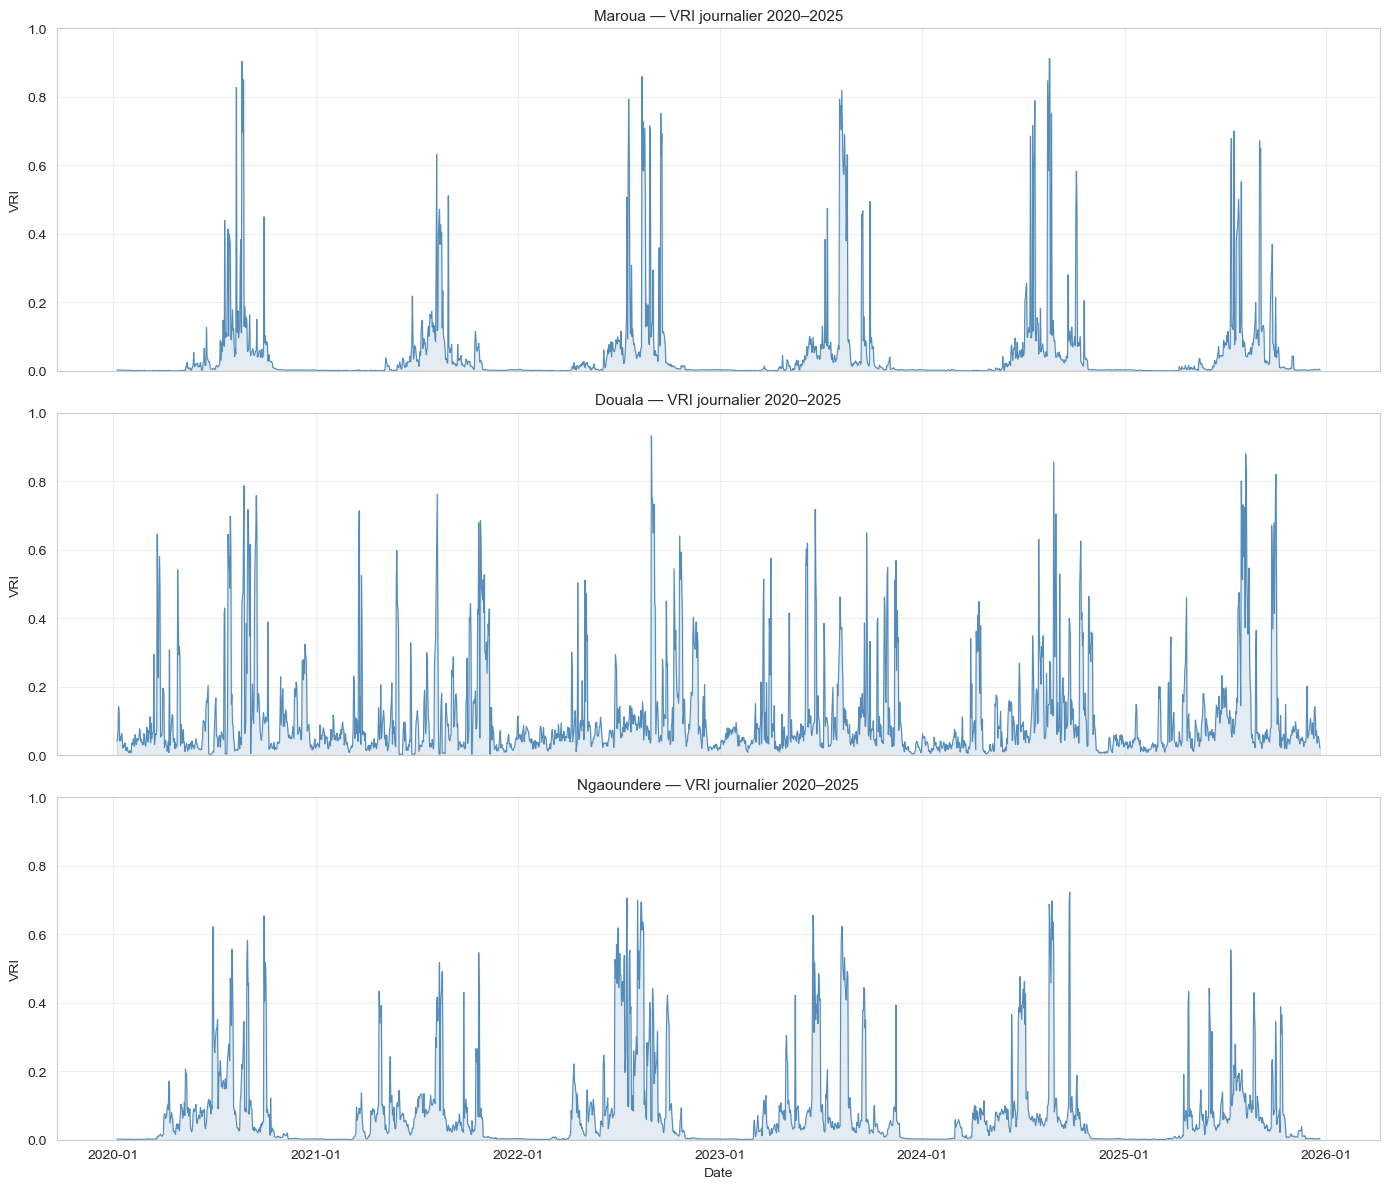

In [10]:
villes_ref = [v for v in ['Maroua','Douala','Ngaoundere'] if v in df_clean['city'].values]
if not villes_ref:
    villes_ref = df_clean['city'].unique()[:3].tolist()

fig, axes = plt.subplots(len(villes_ref), 1, figsize=(14, 4*len(villes_ref)), sharex=True)
if len(villes_ref) == 1: axes = [axes]
for ax, ville in zip(axes, villes_ref):
    s = df_clean[df_clean['city'] == ville]
    ax.plot(s['time'], s['VRI'], linewidth=0.8, color='steelblue', alpha=0.9)
    ax.fill_between(s['time'], s['VRI'], alpha=0.15, color='steelblue')
    ax.set_title(f'{ville} — VRI journalier 2020–2025', fontsize=11)
    ax.set_ylabel('VRI'); ax.set_ylim(0, 1)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlabel('Date')
plt.tight_layout(); plt.show()


## 10. Décomposition STL
Fs = force de saisonnalité (Wang et al. 2006). Fs > 0.64 → saisonnalité dominante.

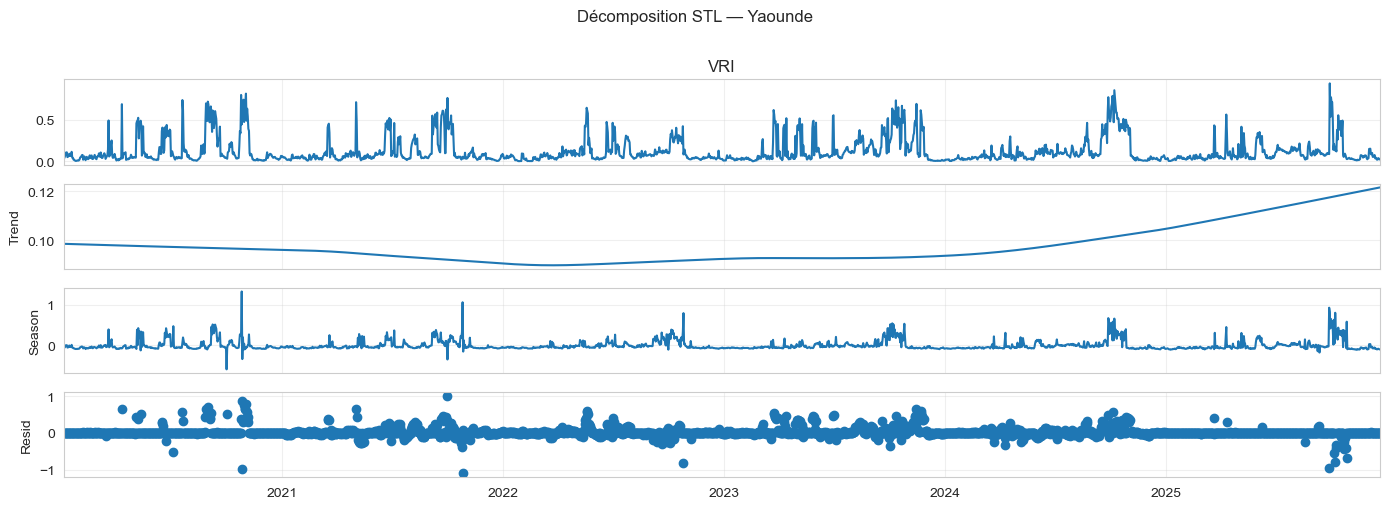

Force saisonnalité (Fs) : 0.268 -> moderee
Force tendance     (Ft) : 0.000 -> moderee


In [11]:
ville_stl = 'Yaounde' if 'Yaounde' in df_clean['city'].values else df_clean['city'].iloc[0]
serie_stl = (df_clean[df_clean['city'] == ville_stl]
             .set_index('time')['VRI'].dropna().asfreq('D').interpolate())
stl = STL(serie_stl, period=365, robust=True)
res = stl.fit()
fig = res.plot()
fig.suptitle(f'Décomposition STL — {ville_stl}', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()
Fs = max(0, 1 - np.var(res.resid) / np.var(res.seasonal + res.resid))
Ft = max(0, 1 - np.var(res.resid) / np.var(res.trend   + res.resid))
print(f'Force saisonnalité (Fs) : {Fs:.3f} -> {"forte" if Fs > 0.64 else "moderee"}')
print(f'Force tendance     (Ft) : {Ft:.3f} -> {"forte" if Ft > 0.64 else "moderee"}')


## 11. ACF / PACF — lags significatifs

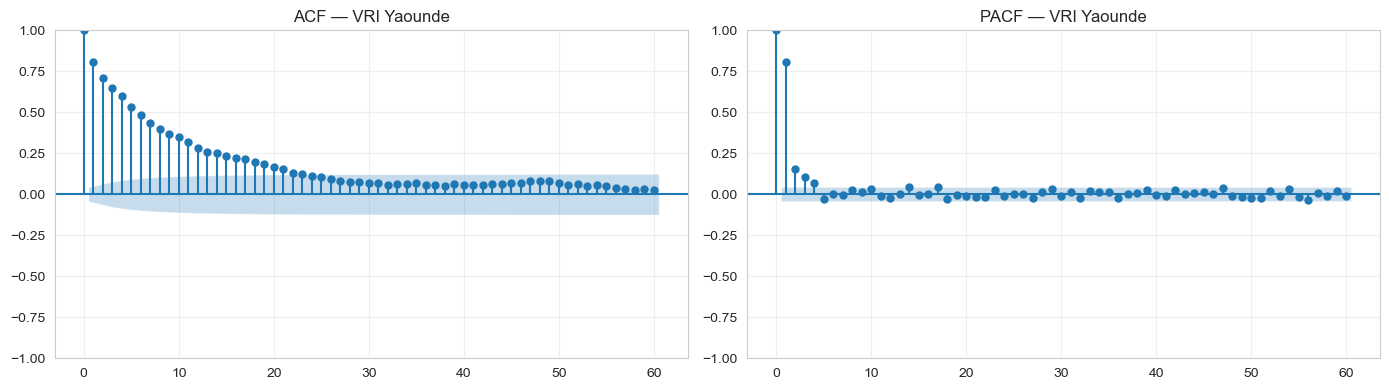

In [12]:
serie_acf = df_clean[df_clean['city'] == ville_stl]['VRI'].dropna()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( serie_acf, lags=60, ax=ax1, alpha=0.05)
plot_pacf(serie_acf, lags=60, ax=ax2, alpha=0.05, method='ywm')
ax1.set_title(f'ACF — VRI {ville_stl}'); ax2.set_title(f'PACF — VRI {ville_stl}')
plt.tight_layout(); plt.show()


## 12. Test de stationnarité ADF par ville

In [13]:
resultats_adf = []
for ville in sorted(df_clean['city'].unique()):
    s = df_clean[df_clean['city'] == ville]['VRI'].dropna()
    if len(s) < 50: continue
    stat, pval = adfuller(s, autolag='AIC')[:2]
    resultats_adf.append({'Ville': ville, 'ADF stat': round(stat,3),
                          'p-value': round(pval,4),
                          'Stationnaire': 'Oui' if pval < 0.05 else 'Non'})
df_adf = pd.DataFrame(resultats_adf)
n_stat = (df_adf['Stationnaire'] == 'Oui').sum()
print(f'Villes stationnaires     : {n_stat} / {len(df_adf)}')
print(f'Villes non-stationnaires : {len(df_adf)-n_stat} / {len(df_adf)}')
print(); print(df_adf.to_string(index=False))


Villes stationnaires     : 40 / 40
Villes non-stationnaires : 0 / 40

      Ville  ADF stat  p-value Stationnaire
Abong-Mbang   -11.609   0.0000          Oui
 Akonolinga    -6.571   0.0000          Oui
      Ambam   -11.467   0.0000          Oui
      Bafia    -6.016   0.0000          Oui
  Bafoussam    -7.218   0.0000          Oui
    Bamenda    -5.499   0.0000          Oui
    Batouri   -11.282   0.0000          Oui
    Bertoua    -9.433   0.0000          Oui
       Buea    -9.902   0.0000          Oui
     Douala   -12.988   0.0000          Oui
    Dschang    -9.116   0.0000          Oui
    Ebolowa    -9.998   0.0000          Oui
       Edea    -9.372   0.0000          Oui
    Foumban    -8.724   0.0000          Oui
     Garoua    -5.145   0.0000          Oui
     Guider    -5.574   0.0000          Oui
   Kousseri    -5.892   0.0000          Oui
      Kribi    -6.947   0.0000          Oui
      Kumba    -7.340   0.0000          Oui
      Kumbo    -9.675   0.0000          Oui
      

## 13. Matrice de corrélation

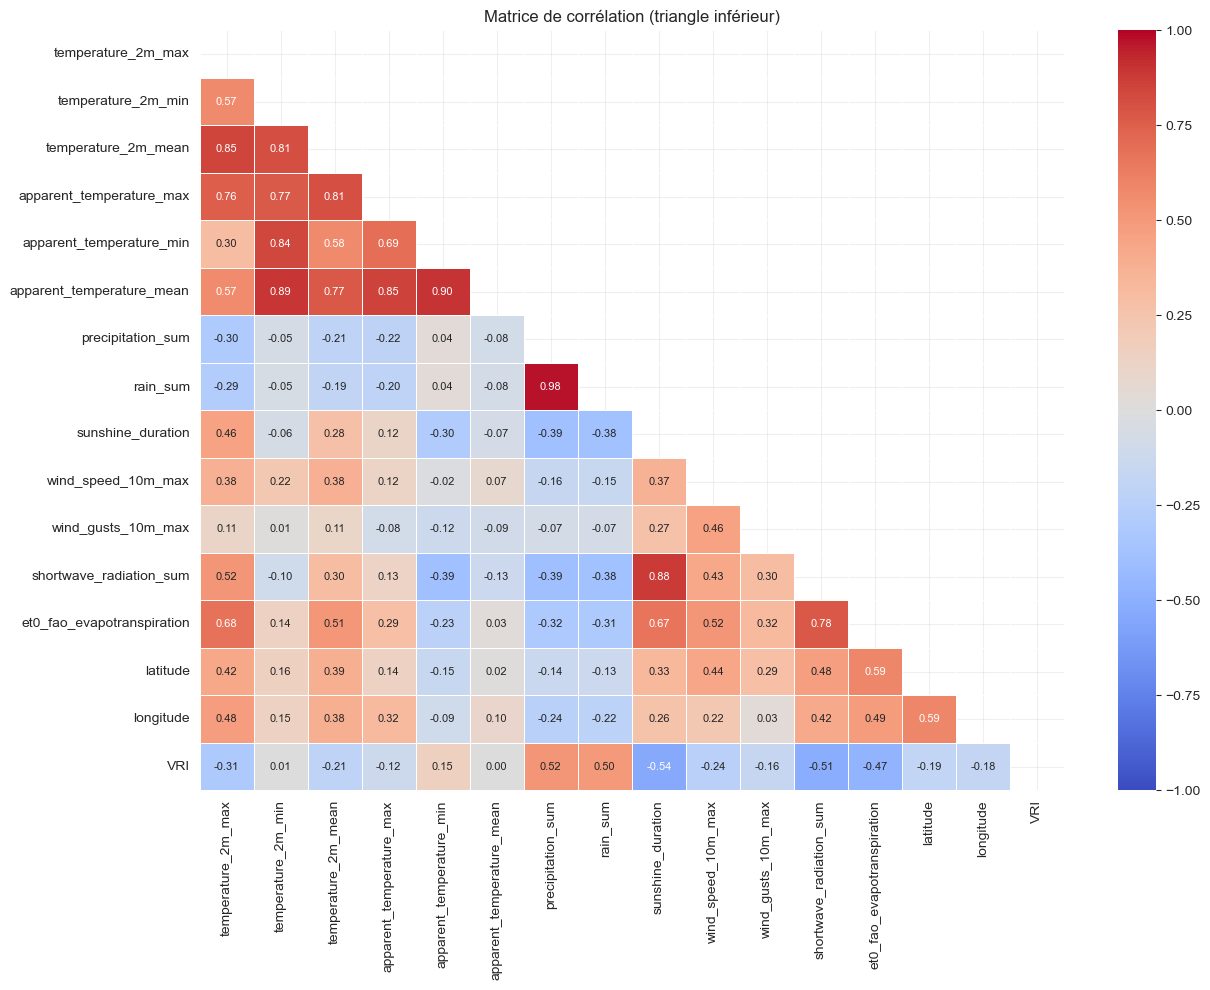

Corrélation des variables avec le VRI :
sunshine_duration            -0.538
precipitation_sum             0.521
shortwave_radiation_sum      -0.509
rain_sum                      0.500
et0_fao_evapotranspiration   -0.475
temperature_2m_max           -0.312
wind_speed_10m_max           -0.236
temperature_2m_mean          -0.208
latitude                     -0.186
longitude                    -0.179
wind_gusts_10m_max           -0.161
apparent_temperature_min      0.150
apparent_temperature_max     -0.122
temperature_2m_min            0.005
apparent_temperature_mean     0.000


In [14]:
corr_cols = [c for c in NUMERIC_COLS + ['VRI'] if c in df_clean.columns]
corr_mat  = df_clean[corr_cols].corr()
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.4, mask=mask, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title('Matrice de corrélation (triangle inférieur)')
plt.tight_layout(); plt.show()
target_corr = corr_mat['VRI'].drop('VRI').sort_values(ascending=False, key=abs)
print('Corrélation des variables avec le VRI :')
print(target_corr.round(3).to_string())


## 14. Distribution du VRI par région
Boxplot ordonné par médiane décroissante. Révèle les disparités géo et justifie la modélisation par ville.

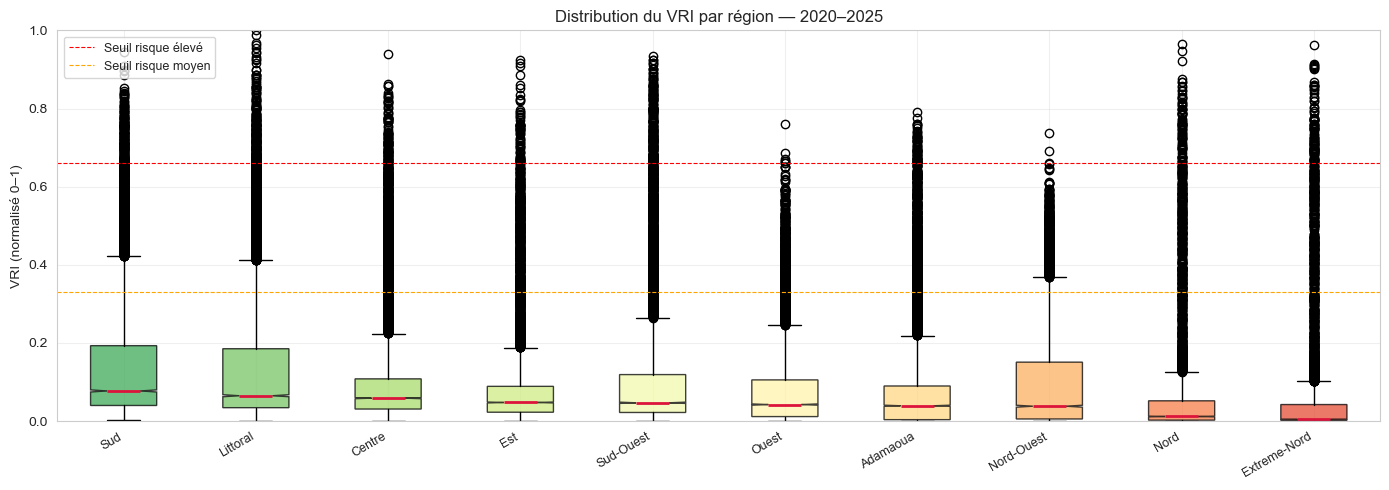

Médiane VRI par région :
              median   mean    std
region                            
Sud            0.077  0.156  0.178
Littoral       0.065  0.153  0.188
Centre         0.058  0.112  0.147
Sud-Ouest      0.047  0.119  0.171
Est            0.047  0.086  0.123
Ouest          0.042  0.090  0.118
Adamaoua       0.039  0.089  0.138
Nord-Ouest     0.038  0.101  0.134
Nord           0.012  0.051  0.113
Extreme-Nord   0.004  0.048  0.118


In [15]:
region_order = (df_clean.groupby('region')['VRI'].median()
                .sort_values(ascending=False).index.tolist())
fig, ax = plt.subplots(figsize=(14, 5))
data_by_region = [df_clean[df_clean['region'] == r]['VRI'].dropna().values
                  for r in region_order]
bp = ax.boxplot(data_by_region, patch_artist=True, notch=True,
                medianprops=dict(color='crimson', linewidth=2))
palette = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(region_order)))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_xticklabels(region_order, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('VRI (normalisé 0–1)')
ax.set_title('Distribution du VRI par région — 2020–2025', fontsize=12)
ax.set_ylim(0, 1)
ax.axhline(0.66, color='red',    linestyle='--', linewidth=0.8, label='Seuil risque élevé')
ax.axhline(0.33, color='orange', linestyle='--', linewidth=0.8, label='Seuil risque moyen')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print('Médiane VRI par région :')
print(df_clean.groupby('region')['VRI'].agg(['median','mean','std']).round(3)
      .sort_values('median', ascending=False).to_string())


## 15. Saisonnalité — heatmap ville × mois
Villes triées Nord → Sud par latitude. Régime bimodal équatorial vs unimodal sahélien.

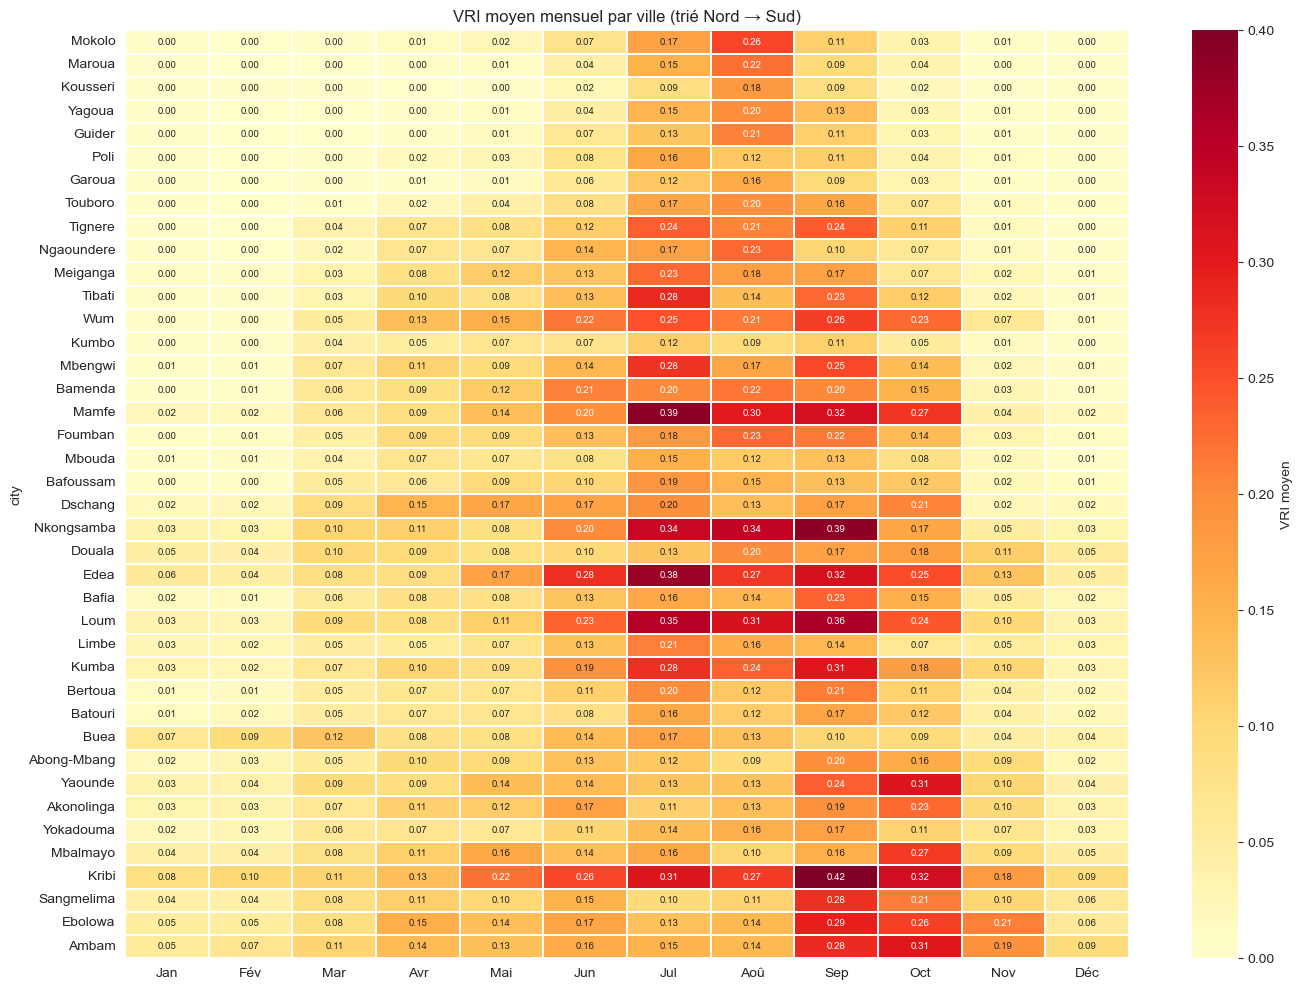

In [16]:
vri_monthly = (df_clean.groupby(['city', df_clean['time'].dt.month])['VRI']
               .mean().unstack(level=1))
vri_monthly.columns = ['Jan','Fév','Mar','Avr','Mai','Jun',
                        'Jul','Aoû','Sep','Oct','Nov','Déc']
city_lat = df_clean.groupby('city')['latitude'].mean().sort_values(ascending=False)
vri_monthly = vri_monthly.reindex(city_lat.index)
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(vri_monthly, cmap='YlOrRd', vmin=0, vmax=0.4,
            linewidths=0.3, linecolor='white',
            annot=True, fmt='.2f', annot_kws={'size': 7},
            ax=ax, cbar_kws={'label': 'VRI moyen'})
ax.set_title('VRI moyen mensuel par ville (trié Nord → Sud)', fontsize=12)
plt.tight_layout(); plt.show()


## 16. Relations VRI / variables météo
Scatter sous-échantillonné avec courbe de tendance. Les non-linéarités justifient les modèles à base d'arbres.

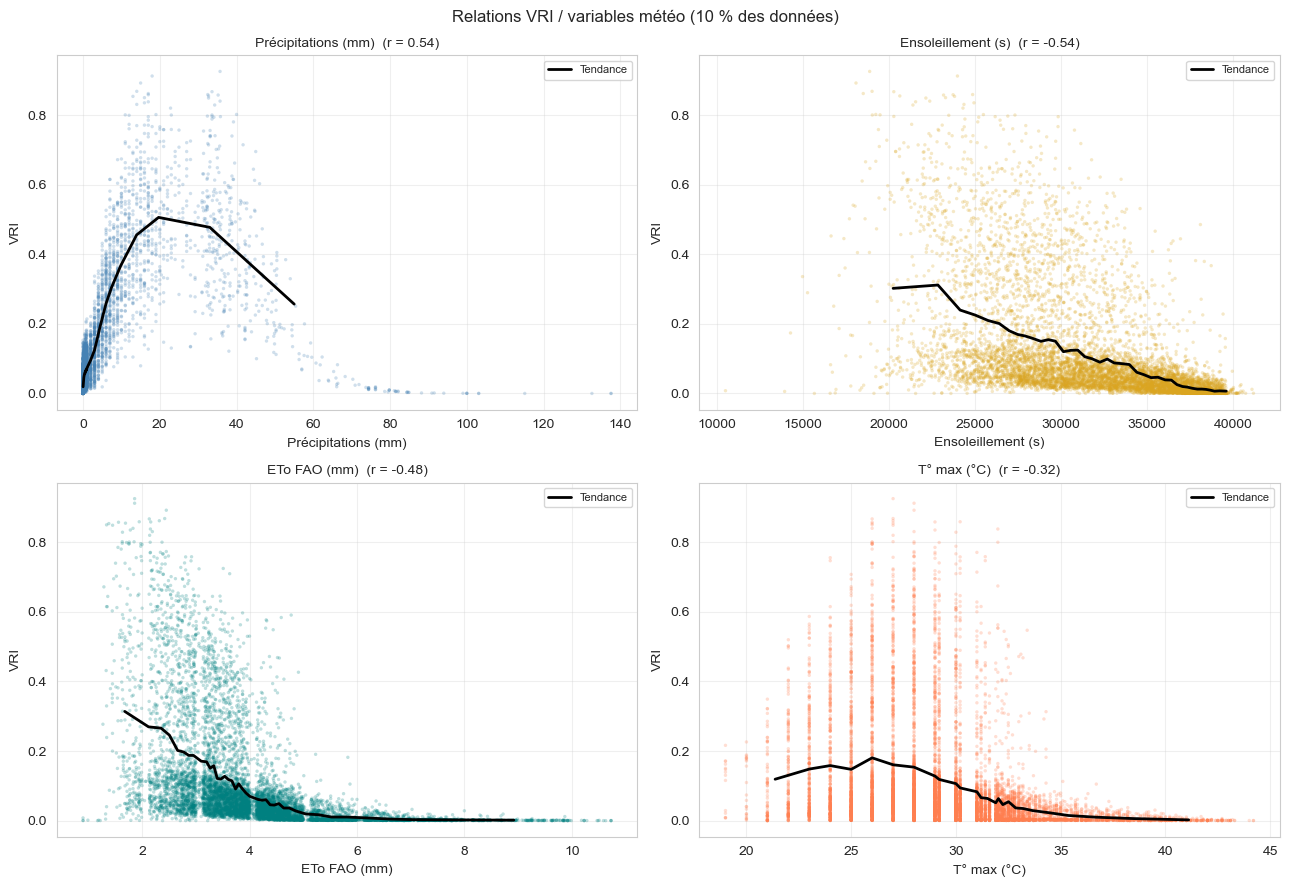

In [17]:
sample = df_clean.sample(frac=0.10, random_state=42)
key_vars = [
    ('precipitation_sum',          'Précipitations (mm)',    'steelblue'),
    ('sunshine_duration',          'Ensoleillement (s)',     'goldenrod'),
    ('et0_fao_evapotranspiration', 'ETo FAO (mm)',           'teal'),
    ('temperature_2m_max',         'T° max (°C)',            'coral'),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9)); axes = axes.flatten()
for ax, (col, xlabel, color) in zip(axes, key_vars):
    if col not in sample.columns: continue
    ax.scatter(sample[col], sample['VRI'], alpha=0.25, s=6, color=color, edgecolors='none')
    tmp = sample[[col,'VRI']].dropna().sort_values(col)
    q_bins = pd.qcut(tmp[col], q=40, duplicates='drop')
    trend  = tmp.groupby(q_bins, observed=True)['VRI'].mean()
    centers= tmp.groupby(q_bins, observed=True)[col].mean()
    ax.plot(centers, trend, color='black', linewidth=2, label='Tendance')
    r = sample[[col,'VRI']].corr().iloc[0,1]
    ax.set_title(f'{xlabel}  (r = {r:.2f})', fontsize=10)
    ax.set_xlabel(xlabel); ax.set_ylabel('VRI'); ax.legend(fontsize=8)
fig.suptitle('Relations VRI / variables météo (10 % des données)', fontsize=12)
plt.tight_layout(); plt.show()


## 17. Tendance interannuelle
Lissage 90 jours sur le VRI moyen toutes villes. Confirme l'absence de tendance pluriannuelle (Ft ≈ 0).

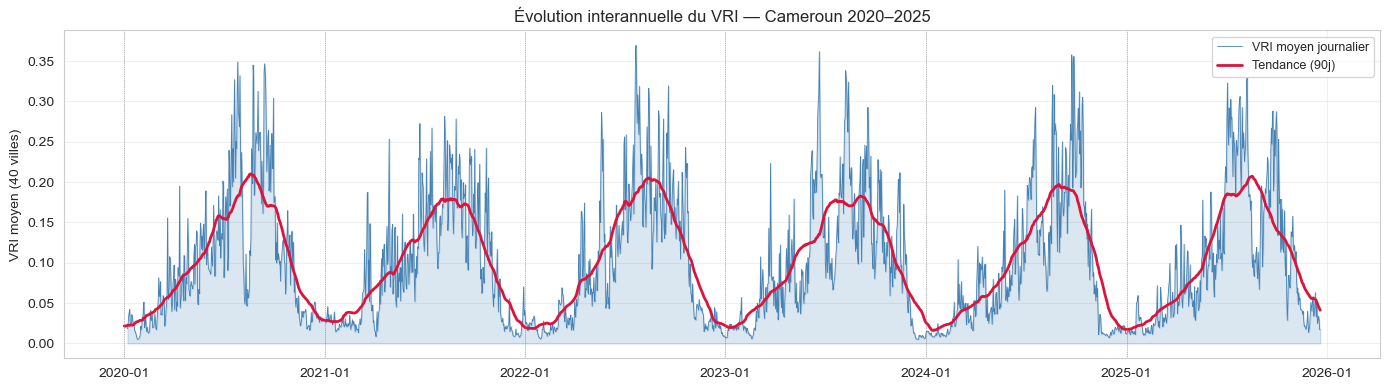

VRI moyen par année :
           mean    std    max
year_tmp                     
2020      0.105  0.154  1.000
2021      0.097  0.142  0.900
2022      0.101  0.155  0.969
2023      0.103  0.149  0.917
2024      0.093  0.143  0.962
2025      0.103  0.152  0.944


In [18]:
vri_daily = (df_clean.groupby('time')['VRI'].mean().reset_index()
             .rename(columns={'VRI':'VRI_mean'}))
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(vri_daily['time'], vri_daily['VRI_mean'], alpha=0.20, color='steelblue')
ax.plot(vri_daily['time'], vri_daily['VRI_mean'], linewidth=0.6,
        color='steelblue', label='VRI moyen journalier')
smooth = vri_daily['VRI_mean'].rolling(90, center=True, min_periods=30).mean()
ax.plot(vri_daily['time'], smooth, linewidth=2, color='crimson', label='Tendance (90j)')
for yr in range(2020, 2026):
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='gray', linewidth=0.5, linestyle=':')
ax.set_ylabel('VRI moyen (40 villes)')
ax.set_title('Évolution interannuelle du VRI — Cameroun 2020–2025', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
df_clean['year_tmp'] = df_clean['time'].dt.year
print('VRI moyen par année :')
print(df_clean.groupby('year_tmp')['VRI'].agg(['mean','std','max']).round(3).to_string())
df_clean.drop(columns='year_tmp', inplace=True)


## 19. Lag Plot — auto-dépendance du VRI
Visualise la corrélation entre VRI(t) et VRI(t-k) pour différents décalages.
Un pattern structuré confirme qu'une composante auto-régressive est exploitable.

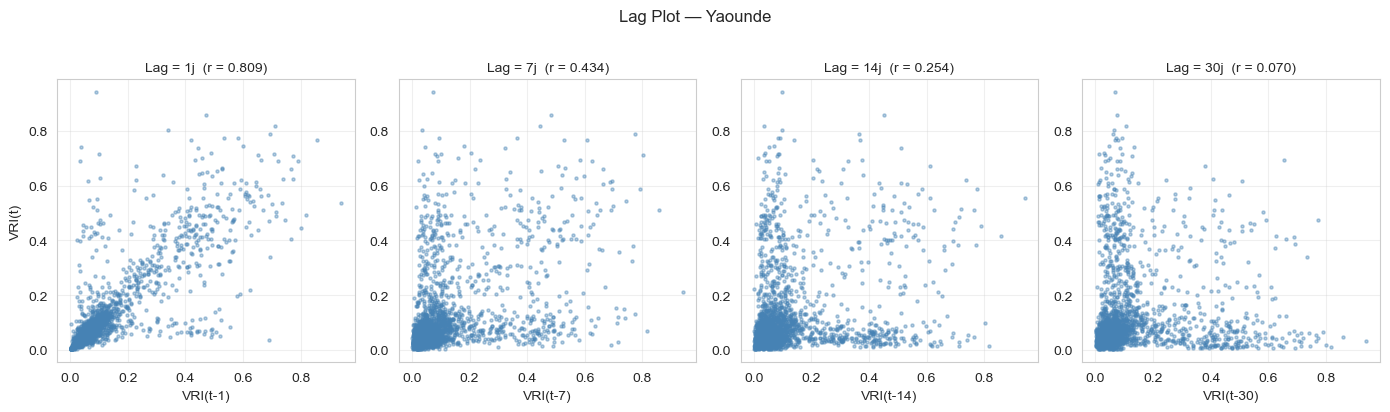

Autocorrélations :
  Lag   1j : 0.8093
  Lag   7j : 0.4341
  Lag  14j : 0.2541
  Lag  30j : 0.0704
  Lag  60j : 0.0233
  Lag  90j : -0.0943
  Lag 180j : -0.0538
  Lag 365j : 0.2902


In [19]:
from pandas.plotting import lag_plot

ville_lag = ville_stl  # ville définie en section 10
serie_lag = df_clean[df_clean['city'] == ville_lag]['VRI'].dropna().reset_index(drop=True)

lags_to_plot = [1, 7, 14, 30]
fig, axes = plt.subplots(1, len(lags_to_plot), figsize=(14, 4))

for ax, lag in zip(axes, lags_to_plot):
    lag_plot(serie_lag, lag=lag, ax=ax, c='steelblue', alpha=0.4, s=5)
    r = serie_lag.autocorr(lag=lag)
    ax.set_title(f'Lag = {lag}j  (r = {r:.3f})', fontsize=10)
    ax.set_xlabel(f'VRI(t-{lag})')
    ax.set_ylabel('VRI(t)' if lag == 1 else '')

fig.suptitle(f'Lag Plot — {ville_lag}', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('Autocorrélations :')
for l in [1, 7, 14, 30, 60, 90, 180, 365]:
    if l < len(serie_lag):
        print(f'  Lag {l:>3}j : {serie_lag.autocorr(lag=l):.4f}')

## 20. Statistiques glissantes (Rolling Mean & Std)
Une moyenne glissante stable et une variance glissante constante confirment visuellement la stationnarité.
Fenêtres de 30 et 90 jours pour distinguer la saisonnalité de court terme de la tendance.

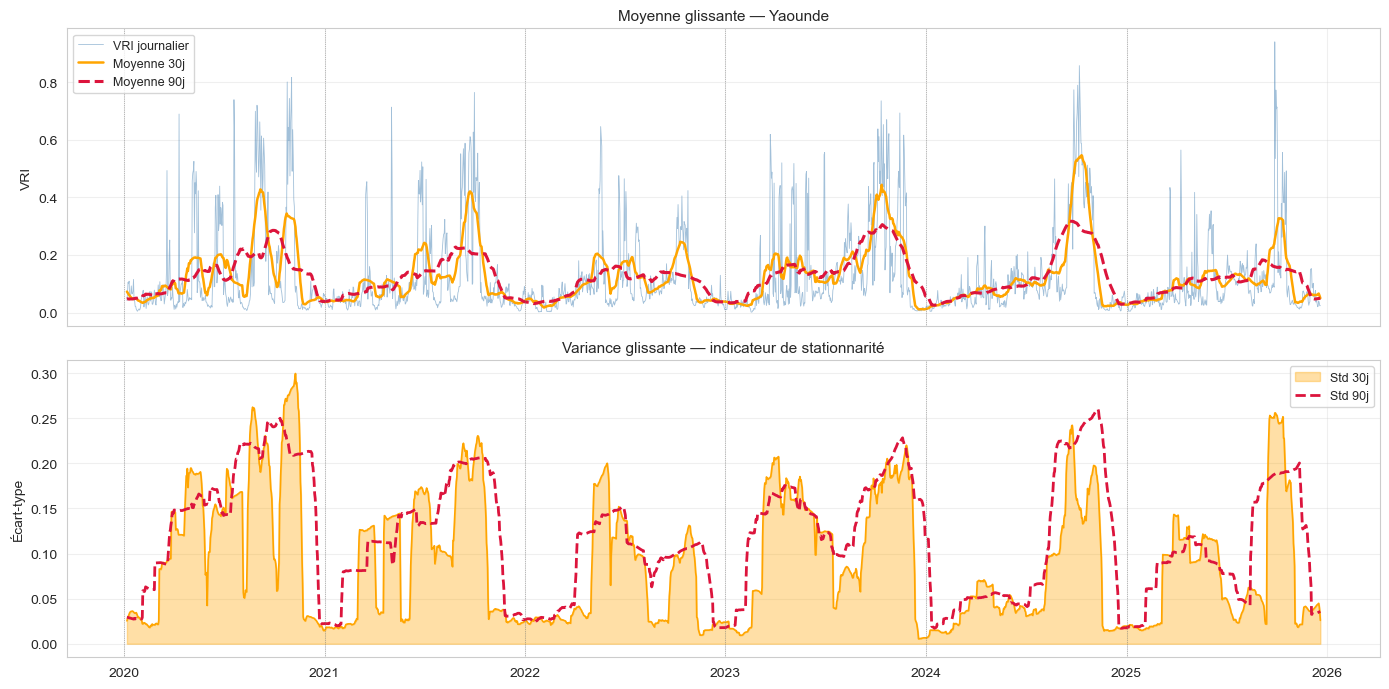

In [20]:
serie_roll = (df_clean[df_clean['city'] == ville_stl]
              .set_index('time')['VRI'].dropna().asfreq('D').interpolate())

roll30  = serie_roll.rolling(window=30,  center=True, min_periods=15)
roll90  = serie_roll.rolling(window=90,  center=True, min_periods=45)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Moyenne glissante
ax1.plot(serie_roll.index, serie_roll.values, color='steelblue',
         linewidth=0.6, alpha=0.5, label='VRI journalier')
ax1.plot(serie_roll.index, roll30.mean(), color='orange',
         linewidth=1.8, label='Moyenne 30j')
ax1.plot(serie_roll.index, roll90.mean(), color='crimson',
         linewidth=2.2, linestyle='--', label='Moyenne 90j')
ax1.set_ylabel('VRI')
ax1.set_title(f'Moyenne glissante — {ville_stl}', fontsize=11)
ax1.legend(fontsize=9)

# Ecart-type glissant
ax2.fill_between(serie_roll.index, roll30.std(), alpha=0.35,
                 color='orange', label='Std 30j')
ax2.plot(serie_roll.index, roll30.std(), color='orange', linewidth=1.2)
ax2.plot(serie_roll.index, roll90.std(), color='crimson',
         linewidth=2, linestyle='--', label='Std 90j')
ax2.set_ylabel('Écart-type')
ax2.set_title('Variance glissante — indicateur de stationnarité', fontsize=11)
ax2.legend(fontsize=9)

for ax in (ax1, ax2):
    for yr in range(2020, 2026):
        ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='gray',
                   linewidth=0.5, linestyle=':')

plt.tight_layout()
plt.show()

## 21. Heatmap calendrier — VRI par semaine et par année
Vue compacte de toute la série : chaque ligne = 1 année, chaque colonne = 1 semaine ISO.
Révèle les pics saisonniers récurrents et les anomalies ponctuelles.

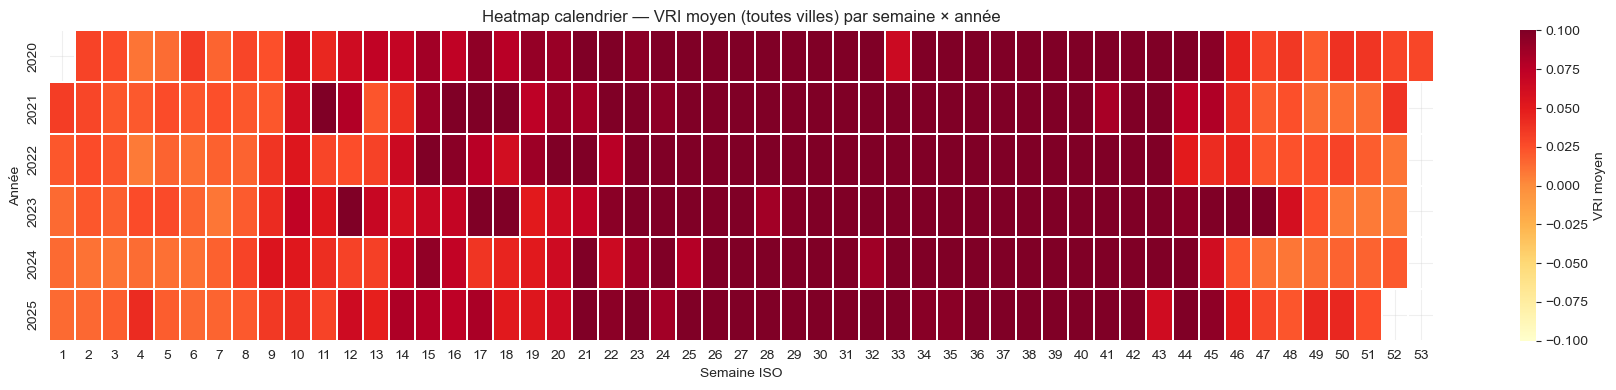

In [21]:
# VRI moyen toutes villes par jour
vri_cal = df_clean.groupby('time')['VRI'].mean().reset_index()
vri_cal['year'] = vri_cal['time'].dt.isocalendar().year.astype(int)
vri_cal['week'] = vri_cal['time'].dt.isocalendar().week.astype(int)
pivot_cal = vri_cal.groupby(['year', 'week'])['VRI'].mean().unstack(level='week')

fig, ax = plt.subplots(figsize=(18, 4))
sns.heatmap(
    pivot_cal,
    cmap='YlOrRd',
    vmin=0, vmax=pivot_cal.values.max(),
    linewidths=0.3,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'VRI moyen'},
    annot=False
)
ax.set_xlabel('Semaine ISO')
ax.set_ylabel('Année')
ax.set_title('Heatmap calendrier — VRI moyen (toutes villes) par semaine × année', fontsize=12)
plt.tight_layout()
plt.show()

## 22. Distribution des changements journaliers (différences 1re ordre)
Δ VRI = VRI(t) − VRI(t-1). Confirme si la série différenciée est gaussienne,
informe le choix des modèles (ARIMA vs SARIMA vs modèles non-paramétriques).

Asymétrie (skewness) : 0.6774
Aplatissement (kurtosis) : 15.8166
Ecart-type ΔVRI : 0.093225


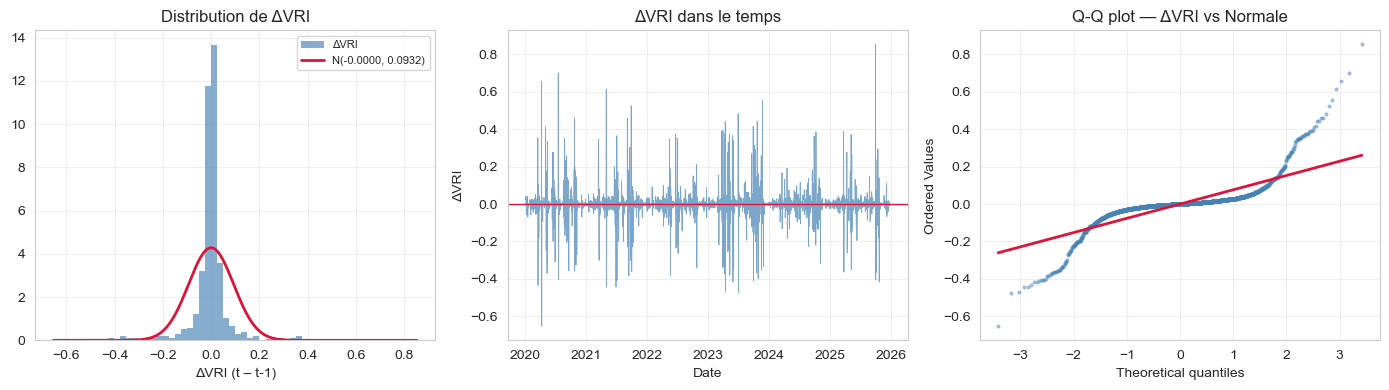

In [22]:
from scipy.stats import norm

serie_diff = serie_roll.diff().dropna()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Histogramme + courbe normale
ax = axes[0]
mu, sigma = serie_diff.mean(), serie_diff.std()
x_range = np.linspace(serie_diff.min(), serie_diff.max(), 300)
ax.hist(serie_diff, bins=60, density=True, color='steelblue',
        alpha=0.65, edgecolor='none', label='ΔVRI')
ax.plot(x_range, norm.pdf(x_range, mu, sigma),
        color='crimson', linewidth=2, label=f'N({mu:.4f}, {sigma:.4f})')
ax.set_title('Distribution de ΔVRI')
ax.set_xlabel('ΔVRI (t – t-1)')
ax.legend(fontsize=8)

# Série différenciée dans le temps
ax = axes[1]
ax.plot(serie_diff.index, serie_diff.values,
        linewidth=0.6, color='steelblue', alpha=0.7)
ax.axhline(0, color='crimson', linewidth=1)
ax.set_title('ΔVRI dans le temps')
ax.set_xlabel('Date')
ax.set_ylabel('ΔVRI')

# Q-Q plot
ax = axes[2]
from scipy.stats import probplot
probplot(serie_diff.values, dist='norm', plot=ax)
ax.set_title('Q-Q plot — ΔVRI vs Normale')
ax.get_lines()[0].set(markersize=2, alpha=0.4, color='steelblue')
ax.get_lines()[1].set(color='crimson', linewidth=2)

print(f'Asymétrie (skewness) : {skew(serie_diff):.4f}')
print(f'Aplatissement (kurtosis) : {kurtosis(serie_diff):.4f}')
print(f'Ecart-type ΔVRI : {sigma:.6f}')

plt.tight_layout()
plt.show()

## 23. Évolution temporelle des classes de risque
Proportion journalière de villes en risque faible / moyen / élevé.
Révèle la dynamique épidémiologique à l'échelle nationale.

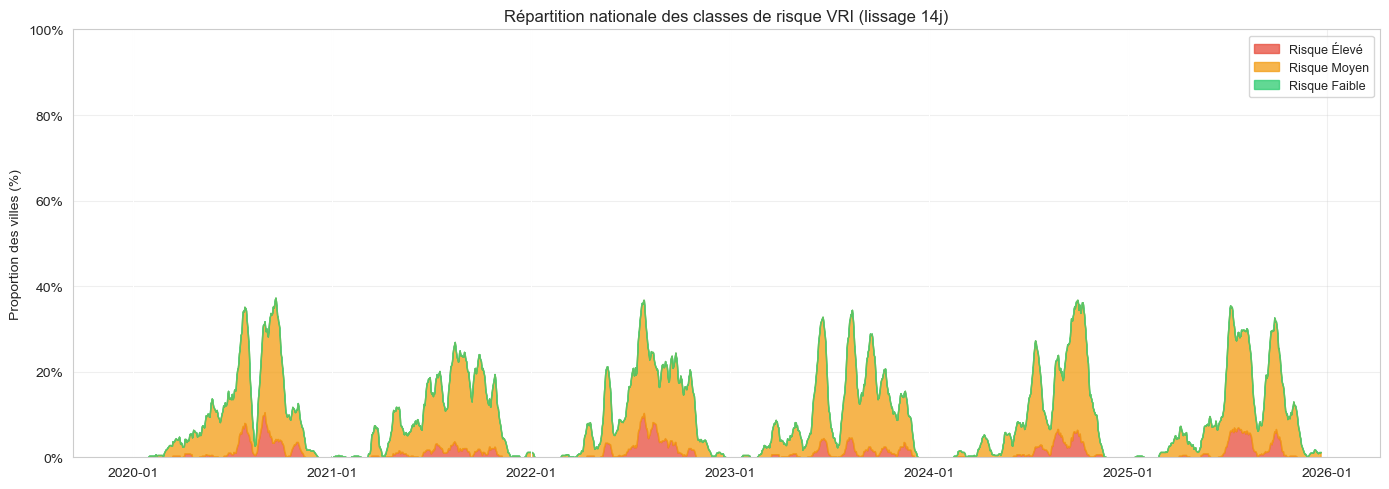

Proportion moyenne par classe (2020–2025) :
risk_class
Faible    90.5
Moyen      8.4
Élevé      1.2


In [23]:
SEUIL_ELEVE = 0.66
SEUIL_MOY   = 0.33

df_risk = df_clean.copy()
df_risk['risk_class'] = pd.cut(
    df_risk['VRI'],
    bins=[-0.001, SEUIL_MOY, SEUIL_ELEVE, 1.001],
    labels=['Faible', 'Moyen', 'Élevé']
)

risk_daily = (df_risk.groupby(['time', 'risk_class'])
              .size().unstack(fill_value=0))
risk_pct   = risk_daily.div(risk_daily.sum(axis=1), axis=0)
risk_smooth = risk_pct.rolling(14, center=True, min_periods=7).mean()

fig, ax = plt.subplots(figsize=(14, 5))
colors = {'Faible': '#2ecc71', 'Moyen': '#f39c12', 'Élevé': '#e74c3c'}
for col in ['Élevé', 'Moyen', 'Faible']:
    if col in risk_smooth.columns:
        ax.fill_between(risk_smooth.index,
                        risk_smooth[col] if col == 'Élevé'
                        else risk_smooth[['Élevé','Moyen'][:(['Élevé','Moyen','Faible'].index(col))+1]].sum(axis=1),
                        risk_smooth[['Élevé','Moyen'][:(['Élevé','Moyen','Faible'].index(col))]].sum(axis=1)
                        if col != 'Élevé' else 0,
                        alpha=0.75, color=colors[col], label=f'Risque {col}')

for yr in range(2020, 2026):
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='white', linewidth=0.8)
ax.set_ylabel('Proportion des villes (%)')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.set_title('Répartition nationale des classes de risque VRI (lissage 14j)', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

print('Proportion moyenne par classe (2020–2025) :')
print((risk_pct.mean() * 100).round(1).to_string())

## 18. Sauvegarde — `df_clean.pkl`

In [24]:
import pickle, os
os.makedirs('../outputs', exist_ok=True)
pickle.dump(df_clean,     open('../outputs/df_clean.pkl',    'wb'), protocol=4)
pickle.dump(NUMERIC_COLS, open('../outputs/numeric_cols.pkl','wb'), protocol=4)
print('Fichiers sauvegardés :')
print('  ../outputs/df_clean.pkl')
print('  ../outputs/numeric_cols.pkl')
print(f'Shape df_clean : {df_clean.shape}')


Fichiers sauvegardés :
  ../outputs/df_clean.pkl
  ../outputs/numeric_cols.pkl
Shape df_clean : (87240, 33)
